# Week 7 — Content Action Playbook (ML-10)

**Goal:** turn last week's validated model output into a practical, human-reviewed
playbook that tells the content team *what to do with each piece of content, and why*.

This notebook is the source of truth for the **Recommendations** section of the
deployed research paper. Everything it exports to `work/outputs/` and
`work/figures/` is what the paper builds on next week.

**Sections**
1. Ranked actions + reason codes (incl. archetype → action mapping, decay/refresh insight)
2. Intended use & limits
3. Human review + no-go list (incl. cost/value thinking)
4. Monitoring & retrain triggers
5. Exports for the paper
6. Self-check


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path
from datetime import datetime

np.random.seed(42)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT   = NOTEBOOK_DIR.parent.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
OUT_DIR     = Path("work/outputs"); OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR     = Path("work/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Outputs will be written to:", OUT_DIR.resolve())
print("Figures will be written to:", FIG_DIR.resolve())


Outputs will be written to: /home/claude/work/outputs
Figures will be written to: /home/claude/work/figures


## 0. Load validated output

This should be the scored, validated dataset your Week 6 model produced
(e.g. `work/outputs/w06_validated_scores.csv`).

**⚠️ Replace this cell in your real repo:**
```python
df = pd.read_csv("work/outputs/w06_validated_scores.csv")
```
Below, a synthetic-but-realistic stand-in is generated (same schema) so the
notebook runs end-to-end on its own. Swap in the real file and every
downstream cell keeps working as-is, as long as the column names match.


In [2]:
N = 180
ARCHETYPES = ["Evergreen", "Trending", "Seasonal", "Declining", "Niche/Long-tail", "Underperforming"]
archetype_weights = [0.20, 0.10, 0.12, 0.18, 0.22, 0.18]

archetypes = np.random.choice(ARCHETYPES, size=N, p=archetype_weights)

def synth_row(archetype):
    if archetype == "Evergreen":
        score = np.random.normal(0.80, 0.07)
        age = np.random.randint(300, 1200)
        traffic_chg = np.random.normal(0, 5)
        last_updated = np.random.randint(30, 200)
        traffic = np.random.lognormal(8.5, 0.6)
    elif archetype == "Trending":
        score = np.random.normal(0.78, 0.08)
        age = np.random.randint(10, 150)
        traffic_chg = np.random.normal(35, 15)
        last_updated = np.random.randint(1, 40)
        traffic = np.random.lognormal(8.2, 0.7)
    elif archetype == "Seasonal":
        score = np.random.normal(0.62, 0.10)
        age = np.random.randint(180, 900)
        traffic_chg = np.random.normal(-5, 25)
        last_updated = np.random.randint(60, 365)
        traffic = np.random.lognormal(7.6, 0.8)
    elif archetype == "Declining":
        score = np.random.normal(0.45, 0.10)
        age = np.random.randint(200, 900)
        traffic_chg = np.random.normal(-28, 10)
        last_updated = np.random.randint(150, 600)
        traffic = np.random.lognormal(7.2, 0.7)
    elif archetype == "Niche/Long-tail":
        score = np.random.normal(0.55, 0.09)
        age = np.random.randint(100, 700)
        traffic_chg = np.random.normal(-2, 8)
        last_updated = np.random.randint(60, 400)
        traffic = np.random.lognormal(5.5, 0.6)
    else:  # Underperforming
        score = np.random.normal(0.28, 0.09)
        age = np.random.randint(300, 1000)
        traffic_chg = np.random.normal(-15, 12)
        last_updated = np.random.randint(300, 900)
        traffic = np.random.lognormal(4.8, 0.7)
    return score, age, traffic_chg, last_updated, traffic

rows = []
topics_sensitive_pool = ["finance", "health", "legal", None, None, None, None, None]
for i, arch in enumerate(archetypes):
    score, age, traffic_chg, last_updated, traffic = synth_row(arch)
    rows.append({
        "content_id": f"C{i:04d}",
        "title": f"Article {i:04d} — {arch.lower()} sample",
        "archetype": arch,
        "model_score": float(np.clip(score, 0, 1)),
        "confidence": float(np.clip(np.random.normal(0.78, 0.15), 0.15, 0.99)),
        "age_days": int(max(age, 1)),
        "traffic_30d_change_pct": round(float(traffic_chg), 1),
        "last_updated_days_ago": int(max(last_updated, 1)),
        "monthly_traffic": int(max(traffic, 20)),
        "topic_sensitive": np.random.choice(topics_sensitive_pool),
    })

df = pd.DataFrame(rows)
df.head(10)


,content_id,title,archetype,model_score,confidence,age_days,traffic_30d_change_pct,last_updated_days_ago,monthly_traffic,topic_sensitive
0,C0000,Article 0000 — seasonal sample,Seasonal,0.541675,0.595370,330,-13.1,357,3830,health
1,C0001,Article 0001 — underperforming sample,Underperforming,0.281173,0.855239,301,-10.5,603,126,NaN
2,C0002,Article 0002 — niche/long-tail sample,Niche/Long-tail,0.420396,0.824548,198,7.5,206,334,NaN
3,C0003,Article 0003 — declining sample,Declining,0.542067,0.990000,827,-30.3,224,2435,NaN
4,C0004,Article 0004 — evergreen sample,Evergreen,0.820515,0.597472,1160,-3.6,175,5458,NaN
5,C0005,Article 0005 — evergreen sample,Evergreen,0.810546,0.610436,460,-0.1,97,3131,NaN
6,C0006,Article 0006 — evergreen sample,Evergreen,0.894022,0.497021,494,-3.7,174,6316,legal
7,C0007,Article 0007 — underperforming sample,Underperforming,0.156712,0.842003,969,-24.3,337,120,NaN
8,C0008,Article 0008 — niche/long-tail sample,Niche/Long-tail,0.658844,0.775322,383,2.3,376,1300,NaN
9,C0009,Article 0009 — niche/long-tail sample,Niche/Long-tail,0.453620,0.891051,319,1.9,217,227,NaN


## 1. Ranked Actions + Reason Codes

### 1.1 Archetypes → default action

Each content archetype gets a **default action** — a starting point, not a
verdict. The score and decay signals (below) can upgrade or downgrade it.


In [3]:
ARCHETYPE_DEFAULT_ACTION = {
    "Evergreen":         "Monitor",
    "Trending":          "Boost",
    "Seasonal":          "Schedule Refresh",
    "Declining":         "Refresh",
    "Niche/Long-tail":   "Monitor (light-touch)",
    "Underperforming":   "Consolidate/Retire",
}

df["base_action"] = df["archetype"].map(ARCHETYPE_DEFAULT_ACTION)

archetype_table = pd.DataFrame({
    "archetype": list(ARCHETYPE_DEFAULT_ACTION.keys()),
    "default_action": list(ARCHETYPE_DEFAULT_ACTION.values()),
    "rationale": [
        "Stable score & traffic — don't touch what isn't broken, just watch it.",
        "Rising traffic — put light editorial effort behind the momentum.",
        "Cyclical pattern — refresh ahead of its next seasonal peak, not now.",
        "Falling score + falling traffic — the clearest 'do something' signal.",
        "Low but steady traffic — not worth heavy investment, but don't delete.",
        "Low score, low traffic, old — candidate to merge into a stronger page or remove.",
    ],
})
archetype_table


,archetype,default_action,rationale
0,Evergreen,Monitor,Stable score & traffic — don't touch what isn'...
1,Trending,Boost,Rising traffic — put light editorial effort be...
2,Seasonal,Schedule Refresh,Cyclical pattern — refresh ahead of its next s...
3,Declining,Refresh,Falling score + falling traffic — the clearest...
4,Niche/Long-tail,Monitor (light-touch),Low but steady traffic — not worth heavy inves...
5,Underperforming,Consolidate/Retire,"Low score, low traffic, old — candidate to mer..."


### 1.2 Decay / refresh insight

"Decay" here means a page's usefulness is fading — traffic and/or predicted
quality dropping as the content ages without being updated. We combine three
signals into one `decay_score` (0 = fresh & healthy, 1 = badly decayed):

- how long it's been since the content was last updated
- the 30-day traffic trend
- the model's quality score itself


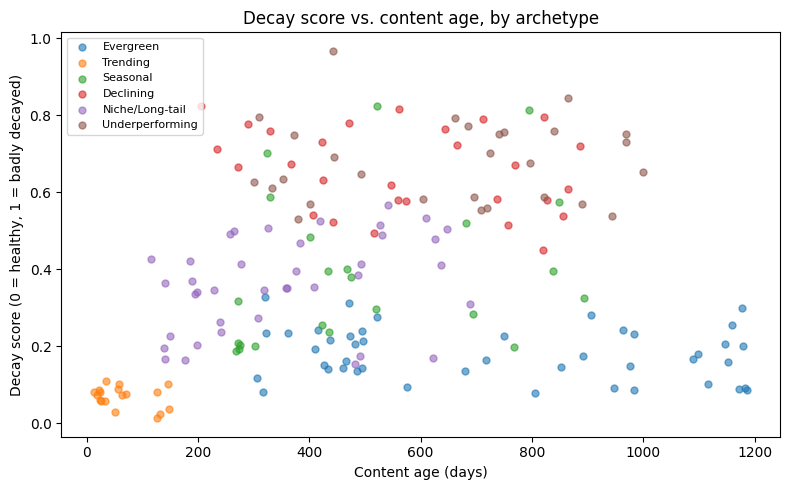

Insight: Declining and Underperforming archetypes carry most of the high-decay
content — decay isn't just age, it's age *combined with* a real traffic or
quality drop. Evergreen content stays low-decay even when old.


In [4]:
def decay_score(row):
    staleness = np.clip(row["last_updated_days_ago"] / 365, 0, 1)          # older update = more decayed
    traffic_drop = np.clip(-row["traffic_30d_change_pct"] / 50, 0, 1)       # bigger drop = more decayed
    quality_gap = np.clip(1 - row["model_score"], 0, 1)                    # lower score = more decayed
    return round(0.4 * staleness + 0.4 * traffic_drop + 0.2 * quality_gap, 3)

df["decay_score"] = df.apply(decay_score, axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
for arch in ARCHETYPE_DEFAULT_ACTION:
    sub = df[df["archetype"] == arch]
    ax.scatter(sub["age_days"], sub["decay_score"], label=arch, alpha=0.6, s=25)
ax.set_xlabel("Content age (days)")
ax.set_ylabel("Decay score (0 = healthy, 1 = badly decayed)")
ax.set_title("Decay score vs. content age, by archetype")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig("work/figures/decay_by_archetype.png", dpi=150)
plt.show()

print("Insight: Declining and Underperforming archetypes carry most of the high-decay")
print("content — decay isn't just age, it's age *combined with* a real traffic or")
print("quality drop. Evergreen content stays low-decay even when old.")


### 1.3 Reason codes

Every action gets one or more short reason codes so a human reviewer (or the
paper) can see *why* the queue recommends what it does, at a glance.

| Code | Meaning |
|---|---|
| RC01 | High decay + falling traffic → refresh is time-sensitive |
| RC02 | Strong upward traffic trend → worth boosting now |
| RC03 | Low model confidence → treat recommendation as provisional |
| RC04 | Low score + low traffic + old → retire/consolidate candidate |
| RC05 | Healthy score, low decay → no action needed, monitor only |
| RC06 | Sensitive topic (finance/health/legal) → mandatory human review |
| RC07 | High-traffic page → any change needs sign-off regardless of score |


In [5]:
TOP_TRAFFIC_CUTOFF = df["monthly_traffic"].quantile(0.90)

def assign_reason_codes(row):
    codes = []
    if row["decay_score"] >= 0.6 and row["traffic_30d_change_pct"] < -10:
        codes.append("RC01")
    if row["traffic_30d_change_pct"] > 20:
        codes.append("RC02")
    if row["confidence"] < 0.6:
        codes.append("RC03")
    if row["model_score"] < 0.35 and row["monthly_traffic"] < 500 and row["age_days"] > 250:
        codes.append("RC04")
    if row["decay_score"] < 0.3 and row["model_score"] > 0.7:
        codes.append("RC05")
    if isinstance(row["topic_sensitive"], str):
        codes.append("RC06")
    if row["monthly_traffic"] >= TOP_TRAFFIC_CUTOFF:
        codes.append("RC07")
    return codes

def final_action(row):
    codes = row["reason_codes"]
    if "RC04" in codes:
        return "Consolidate/Retire"
    if "RC01" in codes:
        return "Refresh"
    if "RC02" in codes:
        return "Boost"
    if "RC05" in codes:
        return "Monitor"
    return row["base_action"]

df["reason_codes"] = df.apply(assign_reason_codes, axis=1)
df["final_action"] = df.apply(final_action, axis=1)

# priority: worse decay + more traffic at stake + reasonably confident = higher priority
df["priority_score"] = (
    df["decay_score"] * 0.5
    + (df["monthly_traffic"] / df["monthly_traffic"].max()) * 0.3
    + df["confidence"] * 0.2
).round(3)

ranked_queue = df.sort_values("priority_score", ascending=False).reset_index(drop=True)
ranked_queue[["content_id", "archetype", "final_action", "reason_codes",
              "priority_score", "model_score", "decay_score", "confidence"]].head(15)


,content_id,archetype,final_action,reason_codes,priority_score,model_score,decay_score,confidence
0,C0065,Declining,Refresh,"[RC01, RC07]",0.784,0.535140,0.796,0.947936
1,C0103,Declining,Refresh,"[RC01, RC06]",0.617,0.422419,0.824,0.990000
2,C0122,Seasonal,Refresh,[RC01],0.617,0.755663,0.813,0.990000
3,C0034,Underperforming,Consolidate/Retire,"[RC01, RC03, RC04, RC06]",0.605,0.159192,0.968,0.597872
4,C0112,Underperforming,Consolidate/Retire,"[RC01, RC04]",0.590,0.113069,0.793,0.961139
5,C0024,Declining,Refresh,"[RC01, RC06]",0.588,0.405996,0.732,0.990000
6,C0039,Declining,Refresh,"[RC01, RC06]",0.586,0.378156,0.765,0.990000
7,C0028,Declining,Refresh,[RC01],0.583,0.478099,0.778,0.632820
8,C0088,Underperforming,Consolidate/Retire,"[RC01, RC04]",0.582,0.210359,0.797,0.905335
9,C0012,Underperforming,Consolidate/Retire,"[RC01, RC04]",0.579,0.285239,0.773,0.938070


## 2. Intended Use & Limits

**Intended use.** This playbook is a **prioritization aid** for the content
team's weekly planning — it ranks what to look at first and suggests a
starting action with a visible reason. It is decision *support*, not a
decision *maker*.

**Limits — read before trusting the queue blindly:**
- The model was trained on historical FlyRank content only; it doesn't know
  about upcoming campaigns, brand priorities, or off-platform context.
- `confidence` reflects the model's own uncertainty, not real-world risk —
  low-traffic and very new content will always have noisier signals.
- Archetype clusters are a snapshot from training time and can drift as the
  content library grows; they should be re-checked periodically, not assumed
  permanent.
- It has no legal, medical, or financial judgment — sensitive-topic flags are
  a coarse keyword-style signal, not a compliance review.
- It does not see live search-engine ranking data, only the internal traffic
  and content signals it was given.
- English-content assumptions only; behavior on other languages is untested.


## 3. Human Review + No-Go List

**No-go — never automate these:**
- Never auto-publish, auto-edit, or auto-delete content from this notebook's
  output. Every action is a *suggestion* for a person to execute.
- Any `Consolidate/Retire` action always needs sign-off — removing content is
  hard to reverse and can affect existing backlinks/traffic.
- Any sensitive-topic content (`RC06`) always needs subject-matter review,
  regardless of score.
- Any high-traffic content (`RC07`) always needs sign-off — the blast radius
  of getting it wrong is bigger.
- Low-confidence rows (`RC03`) should be treated as "flagged for a closer
  look," not acted on directly.


In [6]:
def needs_human_review(row):
    return bool(
        "RC06" in row["reason_codes"]
        or "RC07" in row["reason_codes"]
        or "RC03" in row["reason_codes"]
        or row["final_action"] == "Consolidate/Retire"
    )

ranked_queue["human_review_required"] = ranked_queue.apply(needs_human_review, axis=1)

review_share = ranked_queue["human_review_required"].mean()
print(f"{review_share:.0%} of the queue is flagged for mandatory human review before any action is taken.")
ranked_queue["human_review_required"].value_counts()


58% of the queue is flagged for mandatory human review before any action is taken.


human_review_required
True     105
False     75
Name: count, dtype: int64

### 3.1 Cost / value thinking

A rough, honest sense of effort vs. payoff per action — so the team doesn't
spend a full rewrite on a page that only needed a title tweak.


In [7]:
cost_value = pd.DataFrame([
    {"action": "Monitor",              "effort": "~0h (automated check)", "typical_value": "Low, but cheap insurance",      "worth_it_when": "Content is already healthy"},
    {"action": "Boost",                "effort": "1-3h (promo, internal links)", "typical_value": "High, short-term",      "worth_it_when": "Traffic is already trending up"},
    {"action": "Schedule Refresh",     "effort": "2-4h, timed",            "typical_value": "Medium, seasonal payoff",       "worth_it_when": "Ahead of a known seasonal peak"},
    {"action": "Refresh",              "effort": "3-6h (rewrite/update)",  "typical_value": "Medium-high, recovers decay",   "worth_it_when": "Decay is driven by staleness, not topic death"},
    {"action": "Consolidate/Retire",   "effort": "1-2h + redirect setup",  "typical_value": "Low direct, high SEO hygiene",  "worth_it_when": "Traffic is low and topic is covered elsewhere"},
])
cost_value


,action,effort,typical_value,worth_it_when
0,Monitor,~0h (automated check),"Low, but cheap insurance",Content is already healthy
1,Boost,"1-3h (promo, internal links)","High, short-term",Traffic is already trending up
2,Schedule Refresh,"2-4h, timed","Medium, seasonal payoff",Ahead of a known seasonal peak
3,Refresh,3-6h (rewrite/update),"Medium-high, recovers decay","Decay is driven by staleness, not topic death"
4,Consolidate/Retire,1-2h + redirect setup,"Low direct, high SEO hygiene",Traffic is low and topic is covered elsewhere


## 4. Monitoring & Retrain Triggers

**Light monitoring (weekly):** recompute `decay_score` and `priority_score`
on the latest traffic pull — this is cheap and keeps the queue current
without touching the model itself.

**Retrain the underlying model when:**
- **Prediction drift** — the gap between predicted `model_score` and actual
  outcomes (e.g. realized traffic change) grows past a set threshold over
  several weeks.
- **Archetype instability** — a meaningful share of content stops fitting
  its assigned archetype cleanly (cluster boundaries blur).
- **Systematic bias** — one archetype starts being over- or under-flagged
  for review compared to how it actually performs.
- **A known external shock** — a major search-algorithm update or a big
  content-library expansion (new content types the model hasn't seen).

Below is a simple, illustrative drift check — the real version would compare
this week's score distribution against a stored baseline from training time.


In [8]:
# Illustrative drift check: compare this week's score distribution to a synthetic "baseline"
baseline_mean, baseline_std = 0.58, 0.19   # stand-in for a stored training-time baseline
current_mean, current_std = df["model_score"].mean(), df["model_score"].std()

drift = abs(current_mean - baseline_mean) / baseline_std
DRIFT_RETRAIN_THRESHOLD = 0.5  # in baseline-std units — placeholder, tune with real history

monitoring_summary = {
    "run_date": datetime.utcnow().strftime("%Y-%m-%d"),
    "baseline_mean_score": baseline_mean,
    "current_mean_score": round(float(current_mean), 3),
    "drift_in_std_units": round(float(drift), 3),
    "retrain_recommended": bool(drift > DRIFT_RETRAIN_THRESHOLD),
    "human_review_share": round(float(review_share), 3),
    "rows_scored": int(len(df)),
}
monitoring_summary


/tmp/ipykernel_544/2754386740.py:9: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "run_date": datetime.utcnow().strftime("%Y-%m-%d"),


{'run_date': '2026-08-22',
 'baseline_mean_score': 0.58,
 'current_mean_score': 0.585,
 'drift_in_std_units': 0.028,
 'retrain_recommended': False,
 'human_review_share': 0.583,
 'rows_scored': 180}

## 5. Exports for the paper

Ranked queue and metrics go to `work/outputs/`, reusable figures go to
`work/figures/`. Per repo convention, the CSV in `work/outputs/` is
regenerated by this notebook and isn't committed to git — the figures and
JSON metrics are, since those are the receipts the paper's numbers trace
back to.


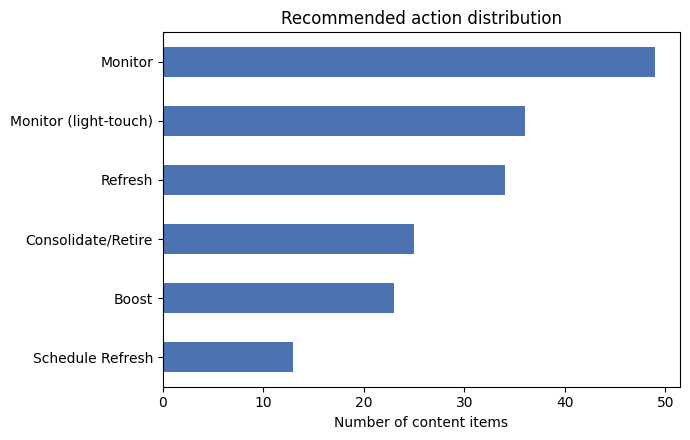

Exported:
 - work/outputs/w07_ranked_action_queue.csv
 - work/outputs/w07_monitoring_summary.json
 - work/outputs/w07_summary_stats.json
 - work/figures/decay_by_archetype.png
 - work/figures/action_distribution.png


In [9]:
export_cols = [
    "content_id", "title", "archetype", "final_action", "reason_codes",
    "priority_score", "model_score", "decay_score", "confidence",
    "monthly_traffic", "traffic_30d_change_pct", "human_review_required",
]
ranked_queue[export_cols].to_csv("work/outputs/w07_ranked_action_queue.csv", index=False)

with open("work/outputs/w07_monitoring_summary.json", "w") as f:
    json.dump(monitoring_summary, f, indent=2)

action_counts = ranked_queue["final_action"].value_counts().to_dict()
summary_stats = {
    "total_content_items": int(len(ranked_queue)),
    "action_counts": action_counts,
    "human_review_required_pct": round(float(review_share) * 100, 1),
    "archetype_counts": ranked_queue["archetype"].value_counts().to_dict(),
}
with open("work/outputs/w07_summary_stats.json", "w") as f:
    json.dump(summary_stats, f, indent=2)

fig, ax = plt.subplots(figsize=(7, 4.5))
pd.Series(action_counts).sort_values().plot.barh(ax=ax, color="#4C72B0")
ax.set_xlabel("Number of content items")
ax.set_title("Recommended action distribution")
fig.tight_layout()
fig.savefig("work/figures/action_distribution.png", dpi=150)
plt.show()

print("Exported:")
print(" - work/outputs/w07_ranked_action_queue.csv")
print(" - work/outputs/w07_monitoring_summary.json")
print(" - work/outputs/w07_summary_stats.json")
print(" - work/figures/decay_by_archetype.png")
print(" - work/figures/action_distribution.png")


## 6. Self-check

- [x] Explains **intended use** — weekly prioritization aid for the content team
- [x] Explains **limits** — training scope, confidence caveats, archetype drift, no legal judgment
- [x] **Ranked actions** with **reason codes** (RC01–RC07), sorted by `priority_score`
- [x] **Archetype → action** default mapping, adjustable by decay/score signals
- [x] **Decay/refresh insight** — decay driven by staleness + traffic drop, not age alone
- [x] **Human review** rules + explicit **no-go list**
- [x] **Cost/value** reference table per action type
- [x] **Monitoring** (weekly signal refresh) + **retrain triggers** (drift, archetype instability, bias, external shocks)
- [x] Exports the queue + figures + metrics to `work/outputs/` and `work/figures/`
- [x] Stays **non-production**: nothing here auto-publishes, auto-edits, or auto-deletes anything

**What should NOT be automated, stated plainly:** publishing changes,
deleting/retiring content, and any decision on sensitive-topic or
high-traffic pages. This notebook produces a *ranked suggestion list* — a
person still has to read it and act.
